In [7]:

files = ["area_prices_monthly", "metro_stations", "off_plan", "rentals", "secondary_sales"]

for f in files:
    df = pd.read_csv(f"archive (3)/{f}.csv")
    print(f"\n=== {f} === shape: {df.shape}")
    summary = pd.DataFrame({
        "dtype": df.dtypes,
        "nulls": df.isnull().sum()
    })
    print(summary)
   

FileNotFoundError: [Errno 2] No such file or directory: 'archive (3)/area_prices_monthly.csv'

In [ ]:
import pandas as pd

sales = pd.read_csv("archive (3)/secondary_sales.csv")

# check if floor nulls line up with property type
print(sales[sales["floor"].isnull()]["property_type"].value_counts())
print("\n---")
print(sales[sales["floor"].notnull()]["property_type"].value_counts())

property_type
4BR_villa    6154
3BR_villa    5214
5BR_villa    4539
6BR_villa    1913
Name: count, dtype: int64

---
property_type
1BR              10190
2BR               8380
studio            5680
3BR               5643
4BR_penthouse     2287
Name: count, dtype: int64


In [ ]:
off_plan = pd.read_csv("archive (3)/off_plan.csv")
rentals = pd.read_csv("archive (3)/rentals.csv")

# tag each with its listing type before combining
sales["listing_type"] = "secondary_sale"
off_plan["listing_type"] = "off_plan"
rentals["listing_type"] = "rental"

# columns every table shares
common_cols = ["id", "date_listed", "community", "zone", "lat", "lon",
                "property_category", "property_type", "bedrooms",
                "area_sqft", "area_m2", "metro_station", "metro_line",
                "metro_distance_min", "to_burj_khalifa_km", "listing_type"]

fact_listings = pd.concat([
    sales[common_cols + ["price_usd", "price_per_sqft_usd"]],
    off_plan[common_cols + ["price_usd", "price_per_sqft_usd"]],
    rentals[common_cols].assign(price_usd=rentals["annual_rent_usd"],
                                  price_per_sqft_usd=rentals["rent_per_sqft_usd"])
], ignore_index=True)

print(fact_listings.shape)
print(fact_listings["listing_type"].value_counts())

(87000, 18)
listing_type
secondary_sale    50000
rental            25000
off_plan          12000
Name: count, dtype: int64


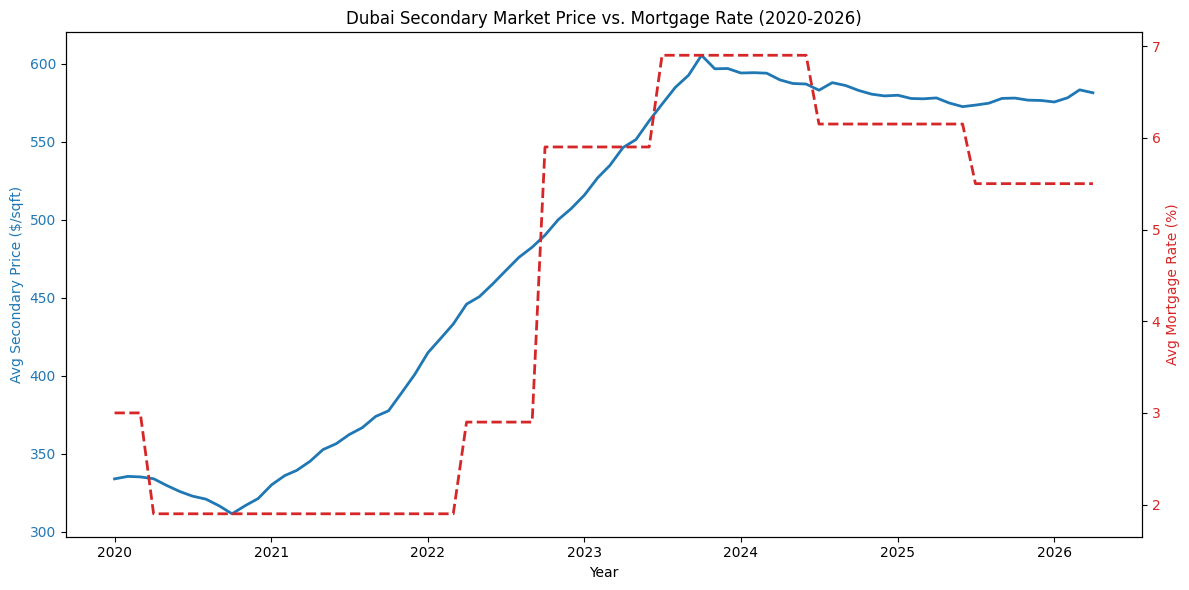

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

area_prices = pd.read_csv("area_prices_monthly.csv")
area_prices["year_month"] = pd.to_datetime(area_prices["year_month"])
area_prices = area_prices.groupby("year_month").agg(
    avg_secondary_price=("secondary_price_per_sqft_usd", "mean"),
    avg_mortgage_rate=("avg_mortgage_rate_pct", "mean")
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(area_prices["year_month"], area_prices["avg_secondary_price"], color="tab:blue", linewidth=2)
ax1.set_xlabel("Year")
ax1.set_ylabel("Avg Secondary Price ($/sqft)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(area_prices["year_month"], area_prices["avg_mortgage_rate"], color="tab:red", linewidth=2, linestyle="--")
ax2.set_ylabel("Avg Mortgage Rate (%)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Dubai Secondary Market Price vs. Mortgage Rate (2020-2026)")
fig.tight_layout()
plt.savefig("charts/price_vs_mortgage_rate.png", dpi=150)
plt.show()

In [8]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\Dell\OneDrive\Documents\data analyst\Dubai real estate market analysis\archive (3)
['area_prices_monthly.csv', 'charts', 'dubai_real_estate.ipynb', 'metro_stations.csv', 'off_plan.csv', 'rentals.csv', 'secondary_sales.csv']


In [ ]:
print("Unique communities:", fact_listings["community"].nunique())
print(sorted(fact_listings["community"].unique()))

print("\nUnique zones:", fact_listings["zone"].nunique())
print(sorted(fact_listings["zone"].unique()))

# check for whitespace/case issues
print("\nAny leading/trailing spaces?",
      (fact_listings["community"].str.strip() != fact_listings["community"]).sum())

Unique communities: 84
['Al Barsha', 'Al Barsha South', 'Al Furjan', 'Al Mamzar', 'Al Nahda', 'Al Qusais', 'Al Reem', 'Al Warqa', 'Arabian Ranches', 'Arabian Ranches 2', 'Arabian Ranches 3', 'Azizi Riviera', 'Bluewaters Island', 'Bukadra', 'Bulgari Resort', 'Bur Dubai', 'Business Bay', 'City Walk', 'DAMAC Lagoons', 'DIFC', 'Damac Hills', 'Damac Hills 2', 'Deira', 'Discovery Gardens', 'Downtown Dubai', 'Dubai Creek Harbour', 'Dubai Festival City', 'Dubai Harbour', 'Dubai Hills Estate', 'Dubai Investment Park', 'Dubai Islands', 'Dubai Marina', 'Dubai Production City', 'Dubai Silicon Oasis', 'Dubai South', 'Dubai Sports City', 'Dubai Studio City', 'Dubailand', 'Emirates Hills', 'Expo City', 'Falcon City of Wonders', 'Green Community', 'International City', 'Jebel Ali', 'Jumeirah 1', 'Jumeirah 2', 'Jumeirah 3', 'Jumeirah Bay Island', 'Jumeirah Beach Residence', 'Jumeirah Golf Estates', 'Jumeirah Islands', 'Jumeirah Lake Towers', 'Jumeirah Park', 'Jumeirah Village Circle', 'Jumeirah Village

In [ ]:
# dim_community: one row per community, with its zone + freehold status
# (take the most common zone/freehold per community, in case of any variation)
dim_community = (
    fact_listings.merge(sales[["id", "is_freehold"]], on="id", how="left")
    .groupby("community")
    .agg(zone=("zone", lambda x: x.mode()[0]))
    .reset_index()
)
print(dim_community.head())
print(dim_community.shape)

# dim_metro: just the metro_stations table, cleaned up
metro_stations = pd.read_csv("archive (3)/metro_stations.csv")
print(metro_stations.head())

# dim_date: unique dates across the fact table, broken into useful parts
fact_listings["date_listed"] = pd.to_datetime(fact_listings["date_listed"])
dim_date = pd.DataFrame({"date": fact_listings["date_listed"].unique()})
dim_date["year"] = dim_date["date"].dt.year
dim_date["month"] = dim_date["date"].dt.month
dim_date["quarter"] = dim_date["date"].dt.quarter
dim_date = dim_date.sort_values("date").reset_index(drop=True)
print(dim_date.head())
print(dim_date.shape)

         community       zone
0        Al Barsha  Al Barsha
1  Al Barsha South  Al Barsha
2        Al Furjan  Al Furjan
3        Al Mamzar  Al Mamzar
4         Al Nahda   Al Nahda
(84, 2)
   station_name line      lat      lon  year_opened  to_burj_khalifa_km
0  UAE Exchange  Red  24.9756  55.0700         2011               32.11
1        Energy  Red  24.9844  55.0866         2011               30.29
2   Ibn Battuta  Red  25.0445  55.1180         2011               23.16
3     Jebel Ali  Red  25.0050  55.1335         2011               25.65
4        Danube  Red  25.0185  55.1230         2011               25.04
        date  year  month  quarter
0 2020-01-01  2020      1        1
1 2020-01-02  2020      1        1
2 2020-01-03  2020      1        1
3 2020-01-04  2020      1        1
4 2020-01-05  2020      1        1
(2311, 4)


In [ ]:
import os
os.makedirs("data/processed", exist_ok=True)

fact_listings.to_csv("data/processed/fact_listings.csv", index=False)
dim_community.to_csv("data/processed/dim_community.csv", index=False)
metro_stations.to_csv("data/processed/dim_metro.csv", index=False)
dim_date.to_csv("data/processed/dim_date.csv", index=False)
area_prices = pd.read_csv("archive (3)/area_prices_monthly.csv")
area_prices.to_csv("data/processed/area_prices_monthly.csv", index=False)

print("Saved:", os.listdir("data/processed"))


Saved: ['area_prices_monthly.csv', 'dim_community.csv', 'dim_date.csv', 'dim_metro.csv', 'fact_listings.csv']


In [ ]:
import sqlite3

conn = sqlite3.connect("data/dubai_real_estate.db")

fact_listings.to_sql("fact_listings", conn, if_exists="replace", index=False)
dim_community.to_sql("dim_community", conn, if_exists="replace", index=False)
metro_stations.to_sql("dim_metro", conn, if_exists="replace", index=False)
dim_date.to_sql("dim_date", conn, if_exists="replace", index=False)
area_prices.to_sql("area_prices_monthly", conn, if_exists="replace", index=False)

# quick sanity check
tables = conn.execute("SELECT name FROM sqlite_master WHERE type='table';").fetchall()
print(tables)

conn.close()

[('fact_listings',), ('dim_community',), ('dim_metro',), ('dim_date',), ('area_prices_monthly',)]
